# Comparative analysis of dimension reduction methods and rebalancing techniques in mental health text classification


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re

import kagglehub 
from kagglehub import KaggleDatasetAdapter

import spacy
from sklearn.feature_extraction import text

from langdetect import detect, DetectorFactory
from langdetect.lang_detect_exception import LangDetectException

In [5]:
dataset_handle = "priyangshumukherjee/mental-health-text-classification-dataset"

# The main unbalanced training data
df_unbalanced = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  dataset_handle,
  "mental_heath_unbanlanced.csv"
)

print("Unbalanced Data Loaded. Shape:", df_unbalanced.shape)
print(df_unbalanced.columns)
print(df_unbalanced.head())

Unbalanced Data Loaded. Shape: (49612, 3)
Index(['Unique_ID', 'text', 'status'], dtype='object')
   Unique_ID                                               text   status
0        0.0                                         oh my gosh  Anxiety
1        1.0  trouble sleeping, confused mind, restless hear...  Anxiety
2        2.0  All wrong, back off dear, forward doubt. Stay ...  Anxiety
3        3.0  I've shifted my focus to something else but I'...  Anxiety
4        4.0  I'm restless and restless, it's been a month n...  Anxiety


In [6]:
class_counts = df_unbalanced['status'].value_counts()
class_pct = df_unbalanced['status'].value_counts(normalize=True) * 100

print("Class Distribution:")
for label, count in class_counts.items():
    print(f"{label}: {count} ({class_pct[label]:.2f}%)")

print("\nMissing values:")
print(df_unbalanced.isnull().sum())

Class Distribution:
Normal: 18391 (37.07%)
Depression: 14506 (29.24%)
Suicidal: 11212 (22.60%)
Anxiety: 5503 (11.09%)

Missing values:
Unique_ID    9600
text            0
status          0
dtype: int64


## Data cleaning process

In [7]:
duplicate_count = df_unbalanced.duplicated().sum()
print(f"Duplicate across the whole rows: {duplicate_count}")

text_duplicates = df_unbalanced.duplicated(subset=['text']).sum()
print(f"Duplicate text entries: {text_duplicates}")

if text_duplicates > 0:
    print("Some duplicate entries:")
    display(df_unbalanced[df_unbalanced.duplicated(subset=['text'], keep=False)].sort_values(by='text').head(5))

df_unbalanced = df_unbalanced.drop_duplicates(subset=['text'], keep='first')
print(f"\nDataset size after removing duplicates: {df_unbalanced.shape[0]}")

Duplicate across the whole rows: 0
Duplicate text entries: 667
Some duplicate entries:


,Unique_ID,text,status
39998,53027.0,"""Buy Friends"" comment? My mother doesn't have ...",Anxiety
39233,52041.0,"""Buy Friends"" comment? My mother doesn't have ...",Anxiety
18,18.0,"""No regrets or grudges/angry at things that ha...",Anxiety
307,309.0,"""No regrets or grudges/angry at things that ha...",Anxiety
500,504.0,"""No regrets or grudges/angry at things that ha...",Anxiety



Dataset size after removing duplicates: 48945


In [8]:
DetectorFactory.seed = 42

def is_english(text):
    if len(str(text)) < 3:
        return False
    try:
        return detect(text) == 'en'
    except LangDetectException:
        return False
    
print("Filtering non-English text...")
df_unbalanced = df_unbalanced[df_unbalanced['text'].apply(is_english)].copy()
print(f"Dataset size after language filtering: {len(df_unbalanced)}")

Filtering non-English text...
Dataset size after language filtering: 46295


As part of the data cleaning process, records with duplicate text and those not in English are removed. This results in a reduction in records from **49,612** when the dataset was initially loaded to **46,295**.

### Table showing what usually changes and what stays the same when using Lemmatization.
| Word Category | Original Word(s) | Lemma (Root Form) | Transformation Logic |
| :--- | :--- | :--- | :--- |
| **Verbs** | feeling, felt, feels | **feel** | Reduces all tenses and aspects to the base infinitive. |
| **Nouns** | crises, mice, women | **crisis, mouse, woman** | Converts plural forms to their singular dictionary root. |
| **Adjectives** | better, saddest | **good, sad** | Reduces comparative/superlative forms to the base adjective. |
| **Adverbs** | suddenly, quietly | **suddenly, quietly** | Usually remains the same as adverbs are often base lemmas. |
| **Pronouns** | me, my, myself | **me, my, myself** | **Customized:** Skiping lemmatization here to keep "self-referential" markers. |
| **Mixed** | sleeping, slept | **sleep** | Distinguishes between "sleep" (noun) and "sleep" (verb). |

In [9]:
nlp = spacy.load("en_core_web_sm", disable=['parser', 'ner'])

KEEP_WORDS = {'i','me','my','myself','we','our','ours', 'not', 'no','never','neither','nor'}

CONTRACTION_MAP = {
    "isn't": "is not", "aren't": "are not", "can't": "cannot", 
    "can't've": "cannot have", "could've": "could have", "couldn't": "could not",
    "didn't": "did not", "doesn't": "does not", "don't": "do not",
    "hadn't": "had not", "hasn't": "has not", "haven't": "have not",
    "he'd": "he would", "he'll": "he will", "he's": "he is",
    "i'd": "i would", "i'll": "i will", "i'm": "i am", "i've": "i have",
    "it's": "it is", "let's": "let us", "mightn't": "might not",
    "mustn't": "must not", "shan't": "shall not", "she'd": "she would",
    "she'll": "she will", "she's": "she is", "shouldn't": "should not",
    "they'd": "they would", "they'll": "they will", "they're": "they are",
    "they've": "they have", "weren't": "were not", "what'll": "what will",
    "what're": "what are", "what's": "what is", "what've": "what have",
    "where's": "where is", "who'd": "who would", "who'll": "who will",
    "who're": "who are", "who's": "who is", "who've": "who have",
    "won't": "will not", "wouldn't": "would not", "you'd": "you would",
    "you'll": "you will", "you're": "you are", "you've": "you have", 
    "that's":"that is"
}

def expand_contractions(text, mapping):
    pattern = re.compile(r'\b(' + '|'.join(mapping.keys()) + r')\b')
    return pattern.sub(lambda x: mapping[x.group()], text)

def preprocess_text(text):
    text = text.lower()

    text = expand_contractions(text, CONTRACTION_MAP)
    text = text.replace('/',' ').replace('-', ' ')
    
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+|\#','', text)
    text = re.sub(r'[^a-z\s]', '', text)

    doc = nlp(text)

    tokens = []
    for token in doc:
        if token.text in KEEP_WORDS:
            tokens.append(token.text)
        elif not token.is_stop and not token.is_space:
            tokens.append(token.lemma_)
    return " ".join(tokens)

print("Starting Preprocessing ... ")
df_unbalanced['cleaned_text'] = df_unbalanced['text'].apply(preprocess_text)
print("Preprocessing Complete")

df_unbalanced.to_csv('mental_health_preprocessed.csv', index=False)

Starting Preprocessing ... 
Preprocessing Complete


To preserve the semantic polarity of the statements (so "not feeling good" does not become "feel good," which is the exact opposite meaning), the standard stopword removal process was modified to retain negation terms (e.g., 'not', 'no', 'never'). 

It is also very important to exclude first-person singular pronouns from the stopword list due to self-referential processing (SRP). SRP is crucial for the formation of self-awareness, social cognition, and emotional regulation, as imbalances often contribute to psychiatric conditions such as depression. 


In [14]:
df_unbalanced = pd.read_csv('mental_health_preprocessed.csv')

if 'Unnamed: 0' in df_unbalanced.columns:
    df_unbalanced = df_unbalanced.drop(columns=['Unnamed: 0'])

df_unbalanced['cleaned_text'] = df_unbalanced['cleaned_text'].fillna("")
print(f"Loaded {len(df_unbalanced)} records successfully.")

df_unbalanced = df_unbalanced[df_unbalanced['cleaned_text'].str.strip() != ""].copy()
print(f"Records after removal of empty strings {len(df_unbalanced)}.")

df_unbalanced['word_count'] = df_unbalanced['cleaned_text'].apply(lambda x: len(x.split()))

short_rows = df_unbalanced[df_unbalanced['word_count'] < 3].shape[0]
print(f"Records with fewer than 3 words: {short_rows}")

df_unbalanced = df_unbalanced[df_unbalanced['word_count'] >= 3].copy()
df_unbalanced = df_unbalanced.drop(columns=['word_count'])

print(f"Final record count: {len(df_unbalanced)}")

Loaded 46295 records successfully.
Records after removal of empty strings 46193.
Records with fewer than 3 words: 1873
Final record count: 44320


Class Distribution:
Normal: 14010 (31.61%)
Depression: 14003 (31.60%)
Suicidal: 11081 (25.00%)
Anxiety: 5226 (11.79%)


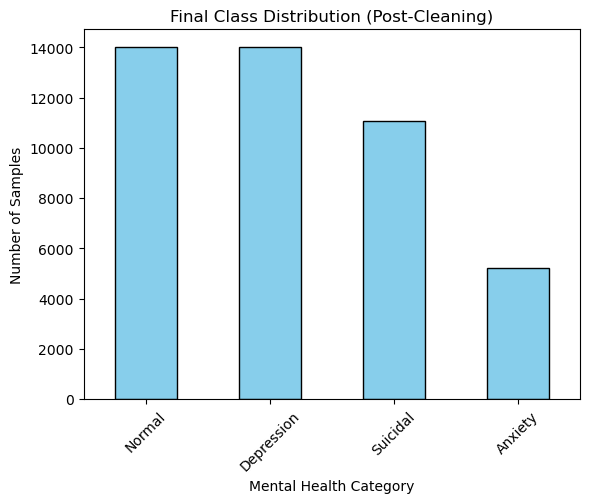

In [16]:
class_counts = df_unbalanced['status'].value_counts()
class_pct = df_unbalanced['status'].value_counts(normalize=True) * 100

print("Class Distribution:")
for label, count in class_counts.items():
    print(f"{label}: {count} ({class_pct[label]:.2f}%)")

class_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Final Class Distribution (Post-Cleaning)')
plt.ylabel('Number of Samples')
plt.xlabel('Mental Health Category')
plt.xticks(rotation=45)
plt.show()